A/B Testing Reminder Strategy
Jumlah data Grup A: 10038
Jumlah data Grup B: 10041
Rata-rata fatigue level Grup A: 5.7269
Rata-rata fatigue level Grup B: 4.347
T-statistic: 46.195
P-value: < 0.001
Kesimpulan: Terdapat perbedaan signifikan antara Grup A dan Grup B.


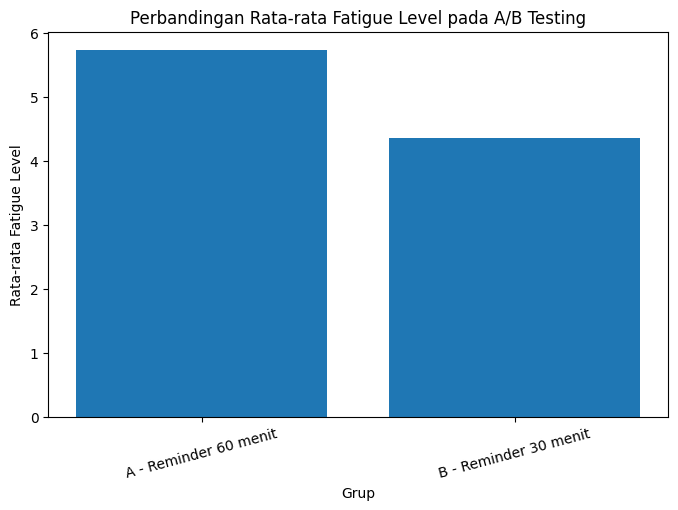

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

df = pd.read_csv("healthy_posture_modeling.csv")

df_ab = df.copy()

median_streak = df_ab["longest_sitting_streak_minutes"].median()

df_ab["ab_group"] = np.where(
    df_ab["longest_sitting_streak_minutes"] > median_streak,
    "A - Reminder 60 menit",
    "B - Reminder 30 menit"
)

metric = "fatigue_level"

group_a = df_ab[df_ab["ab_group"] == "A - Reminder 60 menit"][metric]
group_b = df_ab[df_ab["ab_group"] == "B - Reminder 30 menit"][metric]

t_stat, p_value = ttest_ind(group_a, group_b, equal_var=False)

if p_value < 0.001:
    p_value_text = "< 0.001"
else:
    p_value_text = f"{p_value:.6f}"

print("A/B Testing Reminder Strategy")
print("=" * 40)
print("Jumlah data Grup A:", len(group_a))
print("Jumlah data Grup B:", len(group_b))
print("Rata-rata fatigue level Grup A:", round(group_a.mean(), 4))
print("Rata-rata fatigue level Grup B:", round(group_b.mean(), 4))
print("T-statistic:", round(t_stat, 4))
print("P-value:", p_value_text)

if p_value < 0.05:
    print("Kesimpulan: Terdapat perbedaan signifikan antara Grup A dan Grup B.")
else:
    print("Kesimpulan: Tidak terdapat perbedaan signifikan antara Grup A dan Grup B.")

ab_summary = df_ab.groupby("ab_group")[metric].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.bar(ab_summary["ab_group"], ab_summary[metric])
plt.title("Perbandingan Rata-rata Fatigue Level pada A/B Testing")
plt.xlabel("Grup")
plt.ylabel("Rata-rata Fatigue Level")
plt.xticks(rotation=15)
plt.show()

### Kesimpulan A/B testing

Berdasarkan hasil simulasi A/B testing, grup A merepresentasikan strategi reminder setiap 60 menit, sedangkan grup B merepresentasikan strategi reminder setiap 30 menit. Hasil pengujian menunjukkan bahwa rata-rata fatigue level pada grup A lebih tinggi dibandingkan grup B. Nilai p-value yang diperoleh kurang dari 0,001, sehingga dapat disimpulkan bahwa terdapat perbedaan yang signifikan antara kedua grup.

Hasil ini menunjukkan bahwa strategi reminder setiap 30 menit cenderung lebih efektif dalam menurunkan tingkat kelelahan pengguna dibandingkan reminder setiap 60 menit. Oleh karena itu, aplikasi Healthy Posture Reminder disarankan menggunakan pengingat istirahat yang lebih sering, terutama bagi pengguna dengan durasi duduk yang panjang.

Namun, A/B testing ini masih bersifat simulasi berdasarkan data historis dan pembagian grup menggunakan fitur longest sitting streak. Oleh karena itu, hasil ini digunakan sebagai analisis pendukung awal, dan pengujian langsung terhadap pengguna aplikasi secara nyata tetap diperlukan untuk validasi yang lebih kuat.